# Ordinary Differential Equations (ODE Solvers)
Any ODE (ordinary differential equation) that can be solved analytically is, by definition, not chaotic. ODEs are good models for capturing dynamics in physics, biology, economics, etc. The order of an ordinary differential equation is the number of primes in the highest-order derivative

### Trajectory Nonlinearization through Fields Vector (Jacobian matrix)
consider an ODE as a Field vector, telling us for every point in the state space the direction that is downhill, i.e., what the slop of the landscape is.


In [1]:
def derivativeof_fieldVector(xFieldVector, *params):
    pass # abstraction for derivative implementation

In [2]:
def derivativeof_fieldVector_SHO(xFieldVector=(0,0), k= 2.0, m= 0.5, g=0, betha =0):
    (x,v) = xFieldVector
    xPrime = v
    vPrime = g-(k/m)*x - (betha/m)*v
    return (xPrime, vPrime)

In [3]:
derivativeof_fieldVector_SHO((-1,-2))

(-2, 4.0)

# Single-step ODE Solvers
- They follow the slope

## 1- Forward Euler (Explicit Solver)
- The implementation is for an undamped system like an undamped 2-dimentional Simple harmonic oscillator (SHO)
- with 2 state variables X and V
- The solution for its ODE is a circle in state space, which is cosine and sine sequentially
    

In [3]:
def Forward_Euler_SHO(ic, timestep, finalTimeStep, estimation_timecomplexity=False):    
    trajectories={}
    trajectories[0]=ic
    laststate=ic
    iterations=int(finalTimeStep/timestep)
    o_n=0 # is equal to the number of iterations
    for i in range(iterations):
        fv=trajectories[i] # get the last field vector
        (xprime,vprime) = derivativeof_fieldVector_SHO(fv) # our nearest guess 
        directionslop=(timestep*xprime, timestep*vprime)
        next_position=(directionslop[0]+fv[0], directionslop[1]+fv[1])
        trajectories[i+1]=next_position
        laststate=next_position
        if estimation_timecomplexity:
            o_n+=1            
    return (laststate, trajectories, o_n)

In [7]:
Forward_Euler_SHO((-1,-2), 0.1,  0.5, True)

((-1.5283200000000001, 0.6246399999999999),
 {0: (-1, -2),
  1: (-1.2, -1.6),
  2: (-1.3599999999999999, -1.12),
  3: (-1.472, -0.5760000000000002),
  4: (-1.5296, 0.012799999999999812),
  5: (-1.5283200000000001, 0.6246399999999999)},
 5)

In [44]:
# O(n) by decreasing time steps
Forward_Euler_SHO((-1,-2), 0.2,0.5,True)

((-1.72, -1.04), {0: (-1, -2), 1: (-1.4, -1.6), 2: (-1.72, -1.04)}, 2)

In [45]:
Forward_Euler_SHO((-1,-2), 0.1,0.1)[0]

(-1.2, -1.6)

In [46]:
# O(n) by decreasing time steps
Forward_Euler_SHO((-1,-2), 0.2,1000,True)[2]

5000

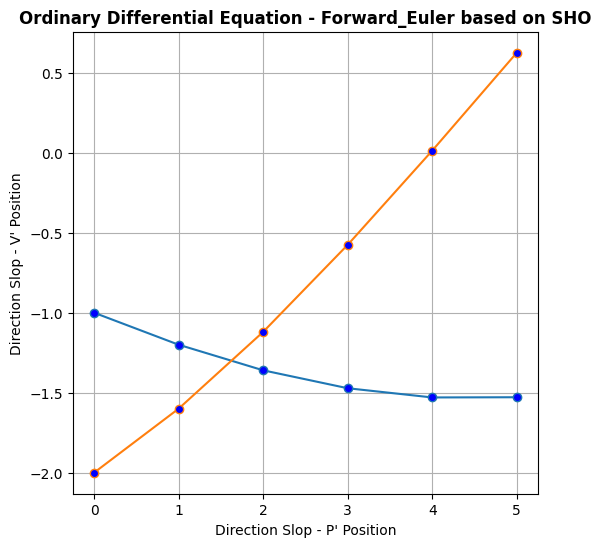

In [29]:
import matplotlib.pyplot as plt

trajectory_fe_5 = Forward_Euler_SHO((-1,-2), 0.1,0.5)[1]
plt.figure(figsize=(6,6))
plt.title(r"Ordinary Differential Equation - Forward_Euler based on SHO", {'fontsize': 12,'fontweight': 'bold'})
plt.xlabel(r"Direction Slop - P' Position")
plt.ylabel(r"Direction Slop - V' Position")
plt.grid()
plt.plot(trajectory_fe_5.values(),marker='o', markerfacecolor='blue')
plt.show()

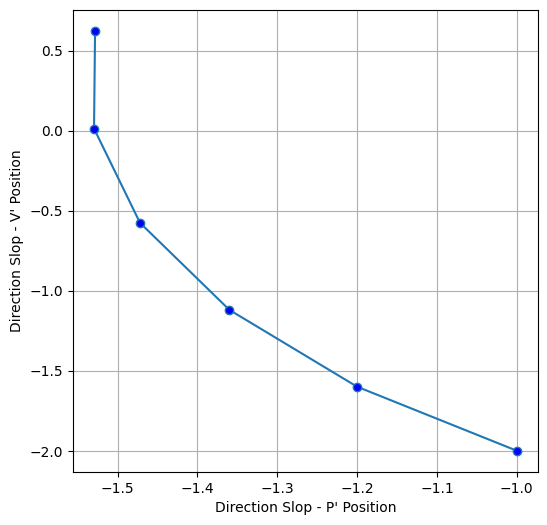

In [31]:
trajectory_fe_coordinates_5={state[0]:state[1] for state in trajectory_fe_5.values()}
plt.figure(figsize=(6,6))
plt.xlabel(r"Direction Slop - P' Position")
plt.ylabel(r"Direction Slop - V' Position")
plt.plot(trajectory_fe_coordinates_5.keys(), trajectory_fe_coordinates_5.values(),marker='o', markerfacecolor='blue')
plt.grid()
plt.show()

### More iterations, higher time complexity and execution order:

In [117]:
Forward_Euler_SHO((-1,-2), 0.1,20) # 200 points

((-38.91484311545908, 119.78538420843641),
 {0: (-1, -2),
  1: (-1.2, -1.6),
  2: (-1.3599999999999999, -1.12),
  3: (-1.472, -0.5760000000000002),
  4: (-1.5296, 0.012799999999999812),
  5: (-1.5283200000000001, 0.6246399999999999),
  6: (-1.465856, 1.235968),
  7: (-1.3422592, 1.8223104),
  8: (-1.16002816, 2.35921408),
  9: (-0.9241067519999999, 2.823225344),
  10: (-0.6417842175999999, 3.1928680448),
  11: (-0.3224974131199999, 3.44958173184),
  12: (0.022460760064000107, 3.578580697088),
  13: (0.3803188297728001, 3.5695963930623997),
  14: (0.7372784690790402, 3.4174688611532797),
  15: (1.0790253551943683, 3.1225574735216637),
  16: (1.3912811025465346, 2.6909473314439163),
  17: (1.6603758356909262, 2.1344348904253025),
  18: (1.8738193247334565, 1.4702845561489322),
  19: (2.0208477803483498, 0.7207568262555495),
  20: (2.092923462973905, -0.08758228588379047),
  21: (2.0841652343855257, -0.9247516710733524),
  22: (1.9916900672781905, -1.7584177648275627),
  23: (1.8158482907

In [10]:
Forward_Euler_SHO((-1,-2), 0.1,10,True)

((-9.99543474762894, 2.0987430280344084),
 {0: (-1, -2),
  1: (-1.2, -1.6),
  2: (-1.3599999999999999, -1.12),
  3: (-1.472, -0.5760000000000002),
  4: (-1.5296, 0.012799999999999812),
  5: (-1.5283200000000001, 0.6246399999999999),
  6: (-1.465856, 1.235968),
  7: (-1.3422592, 1.8223104),
  8: (-1.16002816, 2.35921408),
  9: (-0.9241067519999999, 2.823225344),
  10: (-0.6417842175999999, 3.1928680448),
  11: (-0.3224974131199999, 3.44958173184),
  12: (0.022460760064000107, 3.578580697088),
  13: (0.3803188297728001, 3.5695963930623997),
  14: (0.7372784690790402, 3.4174688611532797),
  15: (1.0790253551943683, 3.1225574735216637),
  16: (1.3912811025465346, 2.6909473314439163),
  17: (1.6603758356909262, 2.1344348904253025),
  18: (1.8738193247334565, 1.4702845561489322),
  19: (2.0208477803483498, 0.7207568262555495),
  20: (2.092923462973905, -0.08758228588379047),
  21: (2.0841652343855257, -0.9247516710733524),
  22: (1.9916900672781905, -1.7584177648275627),
  23: (1.81584829079

In [47]:
Forward_Euler_SHO((-1,-2), 0.11,20)

((-77.21058167692728, 133.02375972199118),
 {0: (-1, -2),
  1: (-1.22, -1.56),
  2: (-1.3916, -1.0232),
  3: (-1.504152, -0.41089600000000015),
  4: (-1.54935056, 0.25093087999999986),
  5: (-1.5217481631999998, 0.9326451263999999),
  6: (-1.419157199296, 1.6022143182079998),
  7: (-1.24291362429312, 2.2266434858982396),
  8: (-0.9979828408443137, 2.7735254805872125),
  9: (-0.6928950379797203, 3.2126379305587105),
  10: (-0.33950486561826215, 3.517511747269787),
  11: (0.04742142658141446, 3.6668938881418227),
  12: (0.45077975427701494, 3.6460284604460003),
  13: (0.851842884926075, 3.447685368564114),
  14: (1.2310882754681276, 3.072874499196641),
  15: (1.569104470379758, 2.531195657990665),
  16: (1.8475359927587311, 1.8407896910235713),
  17: (2.050022858771324, 1.0278738542097297),
  18: (2.1630889827343944, 0.12586379635034706),
  19: (2.1769340003329325, -0.8258953560527865),
  20: (2.086085511167126, -1.7837463161992768),
  21: (1.8898734163852058, -2.7016239411128122),
  22:

### Trajectory generation by more iterations

<Figure size 640x480 with 0 Axes>

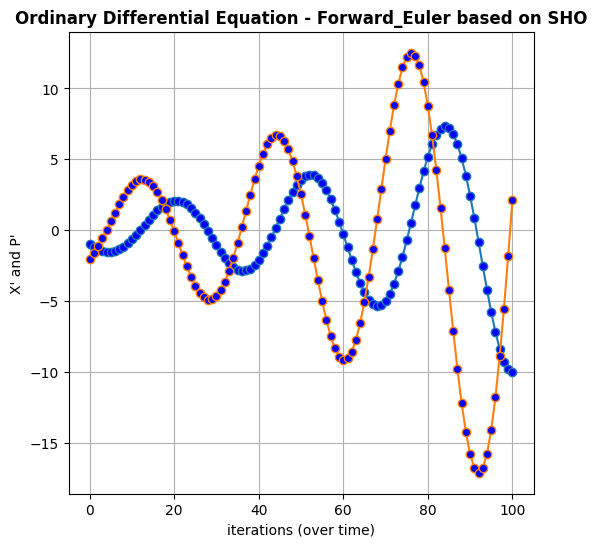

<Figure size 640x480 with 0 Axes>

In [32]:
trajectory_fe_100 = Forward_Euler_SHO((-1,-2), 0.1,10)[1]

plt.figure(figsize=(6,6))
plt.title(r"Ordinary Differential Equation - Forward_Euler based on SHO", {'fontsize': 12,'fontweight': 'bold'})
plt.xlabel(r"iterations (over time)")
plt.ylabel(r"X' and P'")
plt.grid()
plt.plot(trajectory_fe_100.values(),marker='o', markerfacecolor='blue')
plt.figure()


In [34]:
trajectory_fe_coordinates_100={state[0]:state[1] for state in trajectory_fe_100.values()}

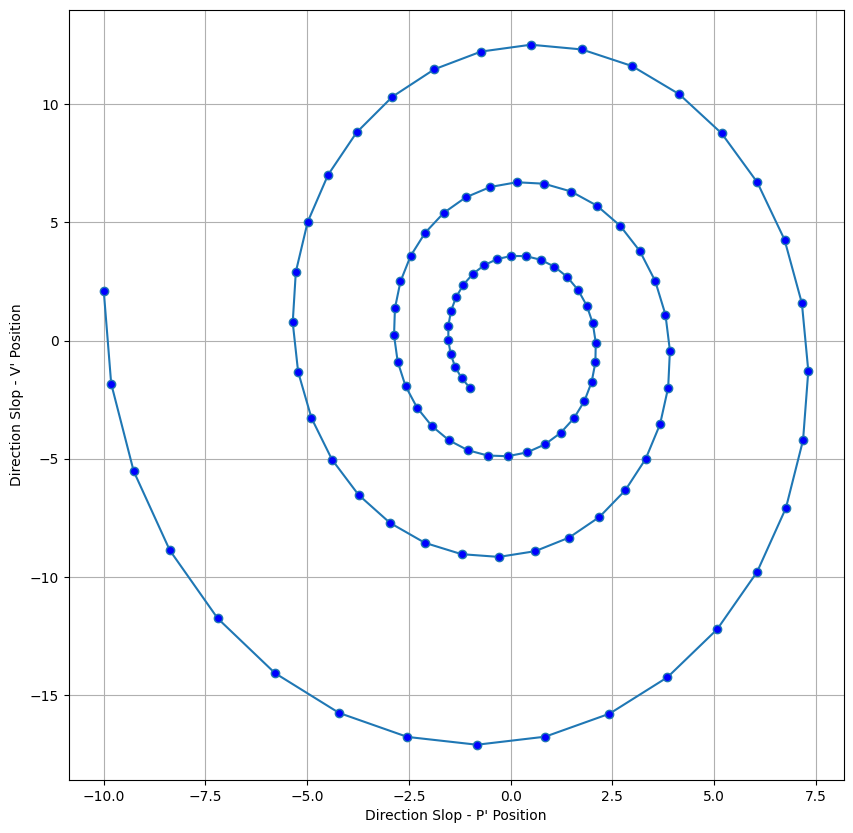

In [35]:
plt.figure(figsize=(10,10))
plt.xlabel(r"Direction Slop - P' Position")
plt.ylabel(r"Direction Slop - V' Position")
plt.grid()
plt.plot(trajectory_fe_coordinates_100.keys(), trajectory_fe_coordinates_100.values(),marker='o', markerfacecolor='blue')
plt.show()

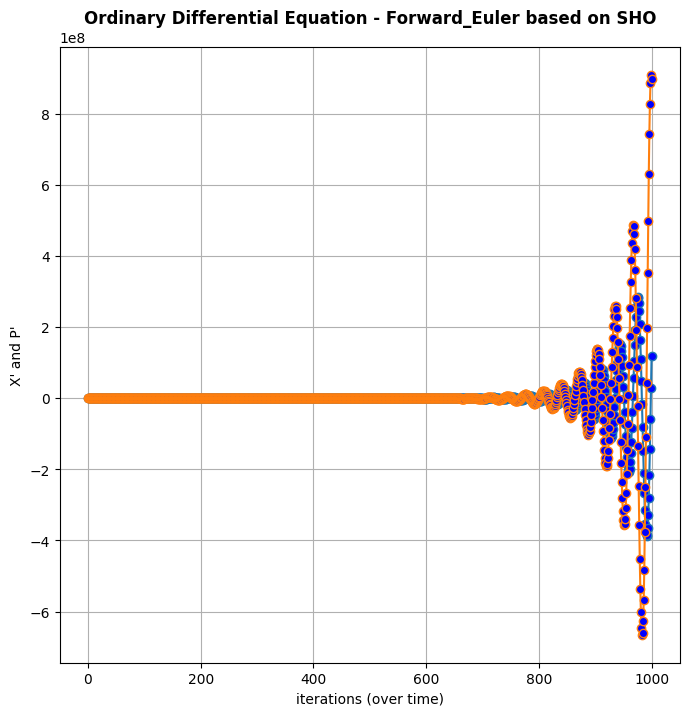

In [36]:
trajectory_fe_1000 = Forward_Euler_SHO((-1,-2), 0.1,100)[1]
plt.figure(figsize=(8,8))
plt.title(r"Ordinary Differential Equation - Forward_Euler based on SHO", {'fontsize': 12,'fontweight': 'bold'})
plt.xlabel(r"iterations (over time)")
plt.ylabel(r"X' and P'")
plt.grid()
plt.plot(trajectory_fe_1000.values(),marker='o', markerfacecolor='blue')
plt.show()

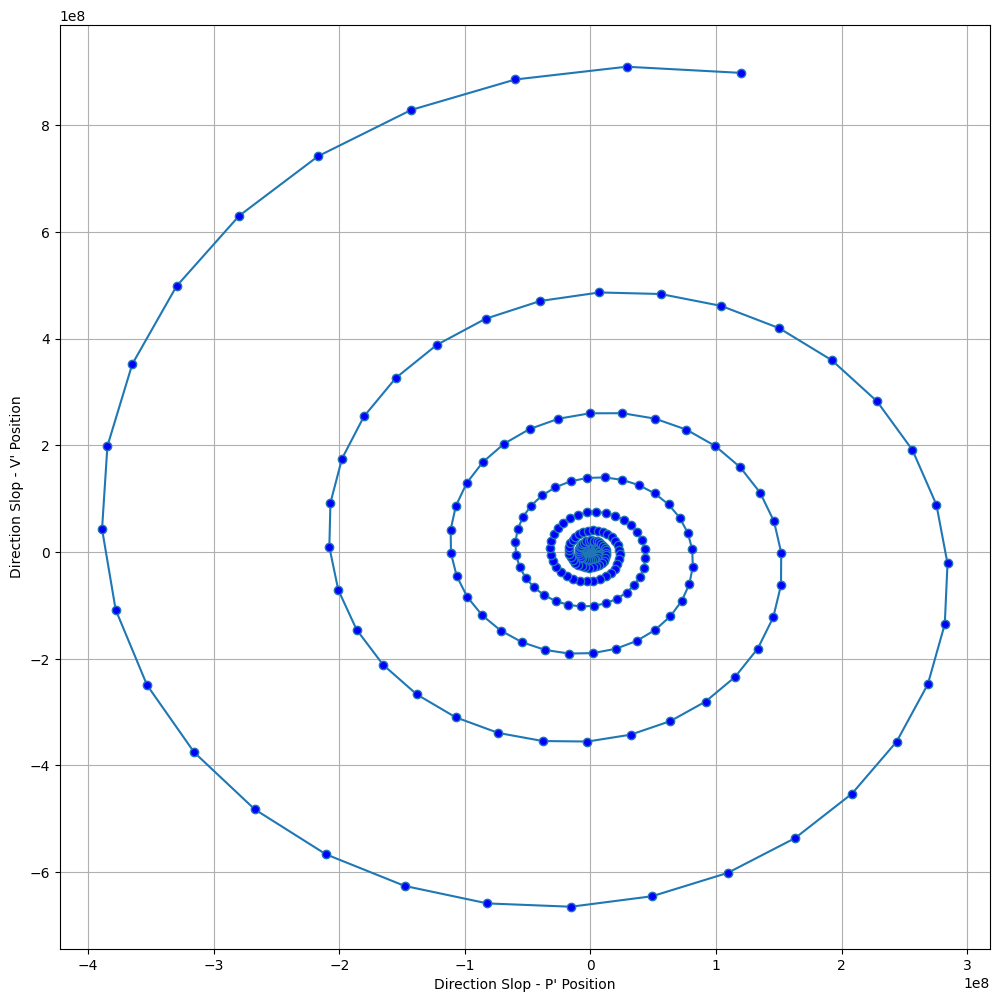

In [37]:
trajectory_fe_coordinates_1000={state[0]:state[1] for state in trajectory_fe_1000.values()}
plt.figure(figsize=(12,12))
plt.xlabel(r"Direction Slop - P' Position")
plt.ylabel(r"Direction Slop - V' Position")
plt.grid()
plt.plot(trajectory_fe_coordinates_1000.keys(), trajectory_fe_coordinates_1000.values(),marker='o', markerfacecolor='blue')
plt.show()

In [48]:
# non-default parameters are taken from caller:

def Forward_Euler_SHO(ic, timestep, finalTimeStep, *sho_args):
    trajectories={}
    trajectories[0]=ic
    laststate=ic
    laststate=ic
    iterations=int(finalTimeStep/timestep)
    o_n = 0 # is equal to the number of iterations
    for i in range(iterations):
        fv=trajectories[i] # get the last field vector
        (xprime,vprime) = derivativeof_fieldVector_SHO(fv, *sho_args) # our nearest guess 
        directionslop=(timestep*xprime, timestep*vprime)
        next_position=(directionslop[0]+fv[0], directionslop[1]+fv[1])
        trajectories[i+1]=next_position
        laststate=next_position        
        o_n+=1
        
    return (laststate, trajectories, o_n)

In [49]:
Forward_Euler_SHO((-1,-2), 0.05,0.5, 2, 1, 0, 0) # k= 2, m= 1, g=0, betha =0

((-1.7208522787468752, -0.6198190556187498),
 {0: (-1, -2),
  1: (-1.1, -1.9),
  2: (-1.195, -1.7899999999999998),
  3: (-1.2845, -1.6704999999999999),
  4: (-1.368025, -1.54205),
  5: (-1.4451275000000001, -1.4052475),
  6: (-1.515389875, -1.26073475),
  7: (-1.5784266125000002, -1.1091957625),
  8: (-1.6338864006250002, -0.9513531012499999),
  9: (-1.6814540556875002, -0.7879644611874999),
  10: (-1.7208522787468752, -0.6198190556187498)},
 10)

### NOTE: 
if you take a bigger time step, we are going to step farther off the trajectory. And in this case, we’ll spiral out faster:

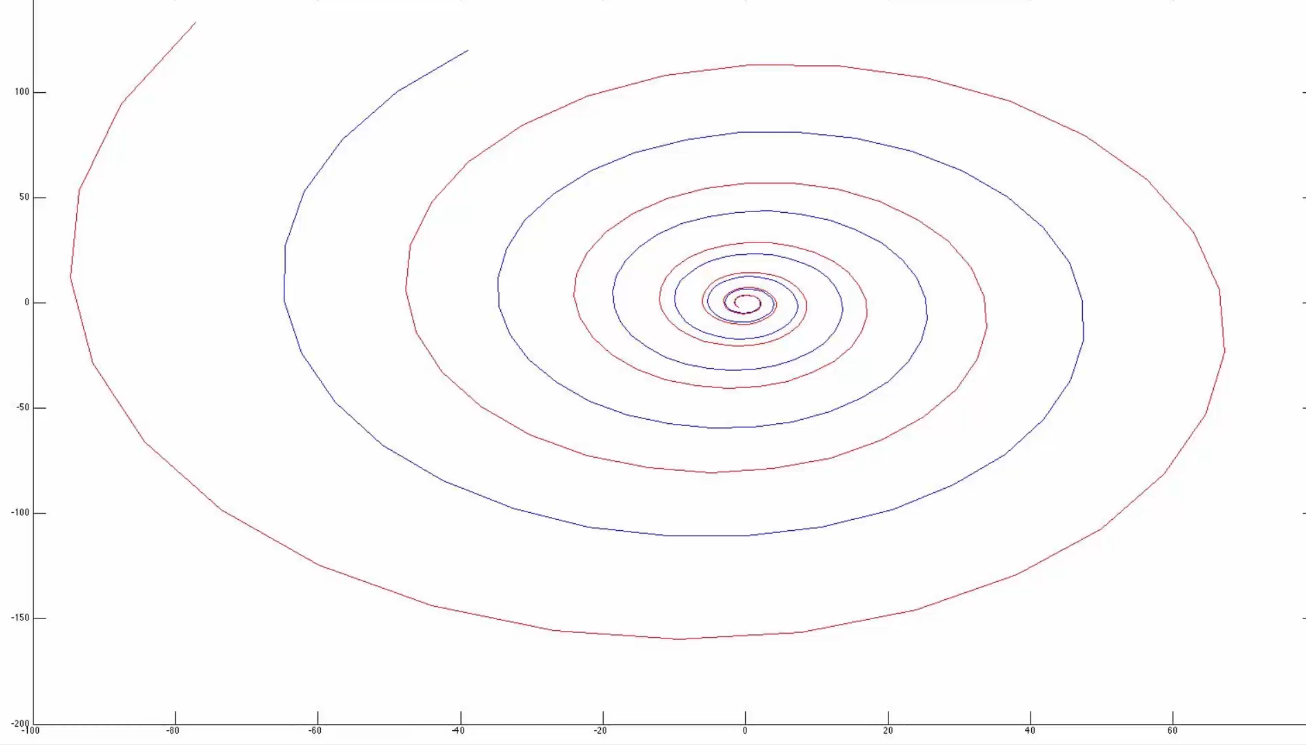

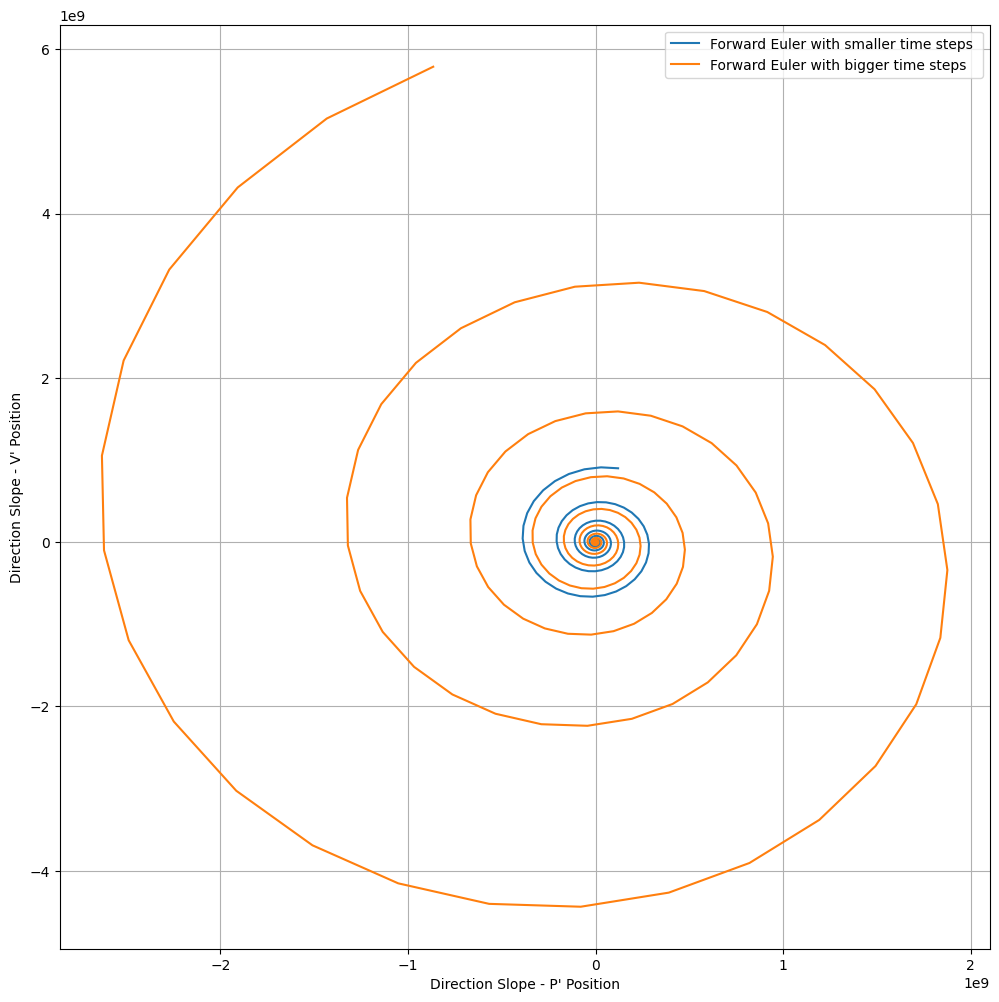

In [38]:
import matplotlib.pyplot as plt

trajectory_fe_smallerts = Forward_Euler_SHO((-1,-2), 0.1, 100)[1]
trajectory_fe_coordinates_smallerts={state[0]:state[1] for state in trajectory_fe_smallerts.values()}
trajectory_fe_biggerts = Forward_Euler_SHO((-1,-2), 0.11, 100)[1]
trajectory_fe_coordinates_biggerts={state[0]:state[1] for state in trajectory_fe_biggerts.values()}

plt.figure(figsize=(12,12))
plt.xlabel(r"Direction Slope - P' Position")
plt.ylabel(r"Direction Slope - V' Position")
plt.grid()
plt.plot(trajectory_fe_coordinates_smallerts.keys(), trajectory_fe_coordinates_smallerts.values(), label='Forward Euler with smaller time steps ' )
plt.legend()
plt.plot(trajectory_fe_coordinates_biggerts.keys(), trajectory_fe_coordinates_biggerts.values(), label='Forward Euler with bigger time steps')
plt.legend()
plt.show()

## 2-	Backward Euler Algorithm (Implicit Solver)
FE figures out where the solution is going to go by walking along the slop. But Forward Euler solution shows poor performance in situation where the landscape is very bumpy, and it makes a mistake when there is a step down in the landscape
In this situation if we use Forward Euler algorithm, we walk directly along the derivative of the current point, this could be a very bad outcome! The improved solution here is taking a test step using forward Euler, then compute the slop at that test step, and then use that slop rather than the slop of the original point to move forward from where started. i.e., BE looks ahead on the landscape. And here the result is a little bit different. the first thing that BE does is taking a FE step. Then it evaluates the derivative out there. Implicit means the BE has some sort of prediction and some sort of correction. And that helps it do a bit better in step down situations that causes such problem for FE.


In [37]:
# def derivativeof_fieldVector_SHO(xFieldVector=(0,0), k= 2.0, m= 0.5, g=0, betha =0):
#     (x,v) = xFieldVector
#     xPrime = v
#     vPrime = g-(k/m)*x - (betha/m)*v
#     return (xPrime, vPrime)


In [13]:
def Backward_Euler_SHO(ic, timestep, finalTimeStep):    
    trajectories={}
    trajectories[0]=ic
    laststate=ic
    iterations=int(finalTimeStep/timestep)
    for i in range(iterations):
        fv=trajectories[i] # get the last field vector
        our_guess = Forward_Euler_SHO(fv, timestep, timestep)  
        # now in each step we calculate the FE for just THAT STEP 
        (xprime,vprime) = derivativeof_fieldVector_SHO(our_guess[0]) # Forward_Euler_SHO((-1,-2), 0.1,0.1)[0] for the last state 
        directionslop=(timestep*xprime, timestep*vprime)
        next_position=(directionslop[0]+fv[0], directionslop[1]+fv[1])
        trajectories[i+1]=next_position
        laststate=next_position
    return (laststate, trajectories)

In [14]:
Backward_Euler_SHO((-1,-2), 0.1,0.5)

((-1.2450968576, 0.6135605248000002),
 {0: (-1, -2),
  1: (-1.1600000000000001, -1.52),
  2: (-1.2656, -0.9951999999999999),
  3: (-1.314496, -0.4491519999999998),
  4: (-1.30683136, 0.09461248000000022),
  5: (-1.2450968576, 0.6135605248000002)})

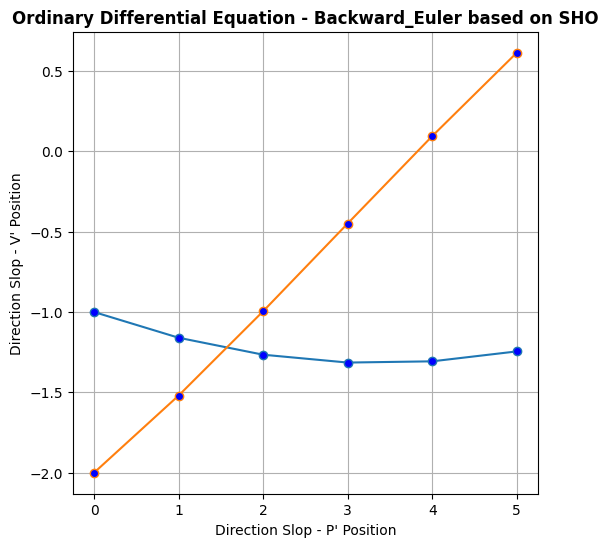

In [56]:
trajectory_be_5 = Backward_Euler_SHO((-1,-2), 0.1,0.5)[1]
plt.figure(figsize=(6,6))
plt.title(r"Ordinary Differential Equation - Backward_Euler based on SHO", {'fontsize': 12,'fontweight': 'bold'})
plt.xlabel(r"Direction Slop - P' Position")
plt.ylabel(r"Direction Slop - V' Position")
plt.grid()
plt.plot(trajectory_be_5.values(),marker='o', markerfacecolor='blue')
plt.show()

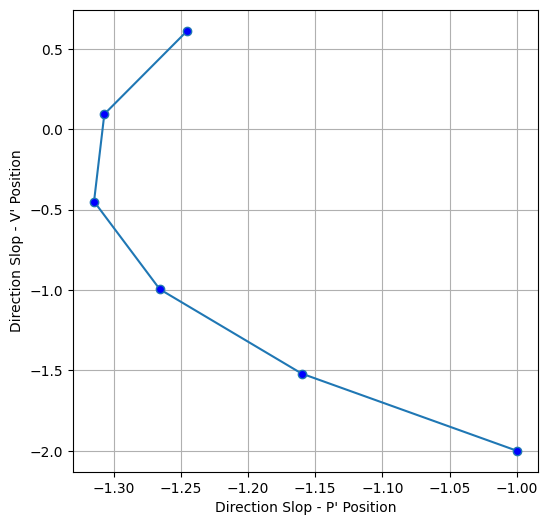

In [55]:
trajectory_be_coordinates_5={state[0]:state[1] for state in trajectory_be_5.values()}
plt.figure(figsize=(6,6))
plt.xlabel(r"Direction Slop - P' Position")
plt.ylabel(r"Direction Slop - V' Position")
plt.plot(trajectory_be_coordinates_5.keys(), trajectory_be_coordinates_5.values(),marker='o', markerfacecolor='blue')
plt.grid()
plt.show()

<Figure size 640x480 with 0 Axes>

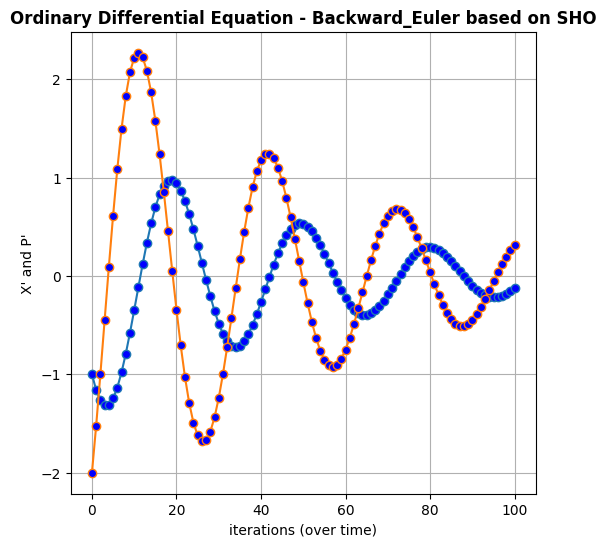

<Figure size 640x480 with 0 Axes>

In [58]:
trajectory_be_100 = Backward_Euler_SHO((-1,-2), 0.1,10)[1]

plt.figure(figsize=(6,6))
plt.title(r"Ordinary Differential Equation - Backward_Euler based on SHO", {'fontsize': 12,'fontweight': 'bold'})
plt.xlabel(r"iterations (over time)")
plt.ylabel(r"X' and P'")
plt.grid()
plt.plot(trajectory_be_100.values(),marker='o', markerfacecolor='blue')
plt.figure()


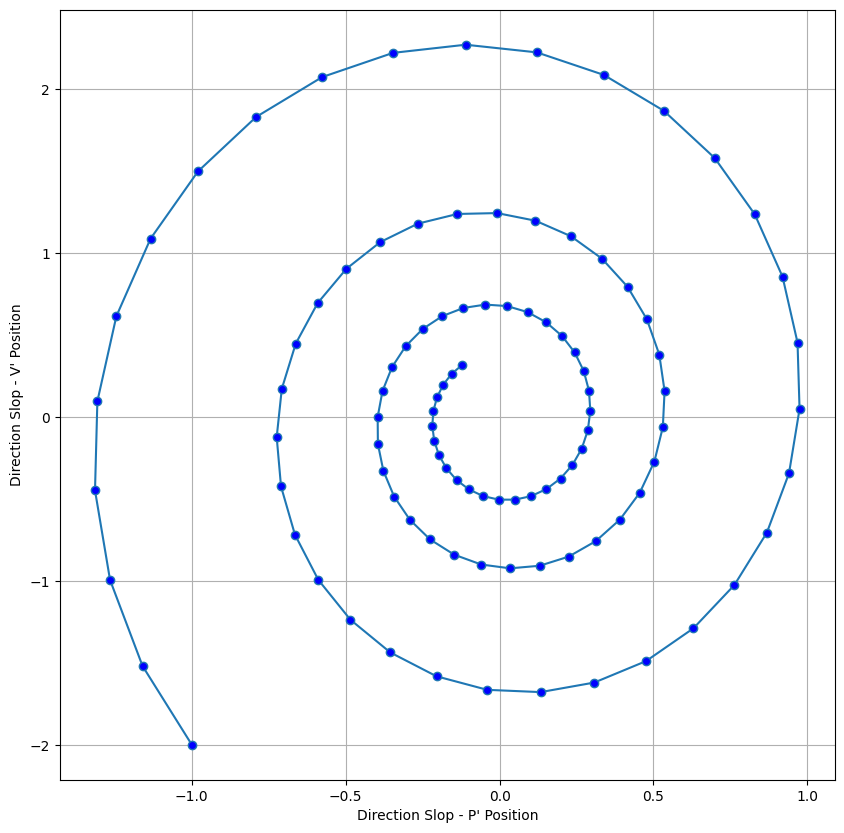

In [59]:
trajectory_be_coordinates_100={state[0]:state[1] for state in trajectory_be_100.values()}

plt.figure(figsize=(10,10))
plt.xlabel(r"Direction Slop - P' Position")
plt.ylabel(r"Direction Slop - V' Position")
plt.grid()
plt.plot(trajectory_be_coordinates_100.keys(), trajectory_be_coordinates_100.values(),marker='o', markerfacecolor='blue')
plt.show()

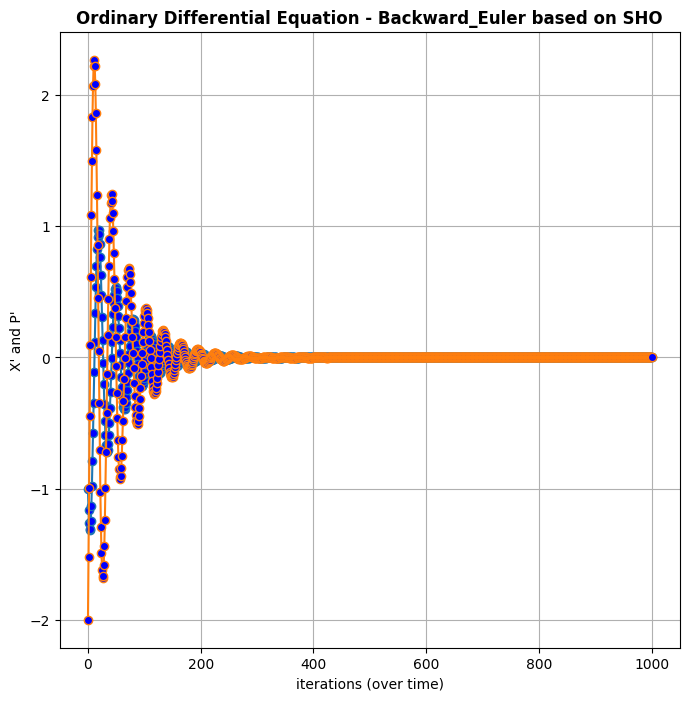

In [61]:

trajectory_be_1000 = Backward_Euler_SHO((-1,-2), 0.1,100)[1]
plt.figure(figsize=(8,8))
plt.title(r"Ordinary Differential Equation - Backward_Euler based on SHO", {'fontsize': 12,'fontweight': 'bold'})
plt.xlabel(r"iterations (over time)")
plt.ylabel(r"X' and P'")
plt.grid()
plt.plot(trajectory_be_1000.values(),marker='o', markerfacecolor='blue')
plt.show()

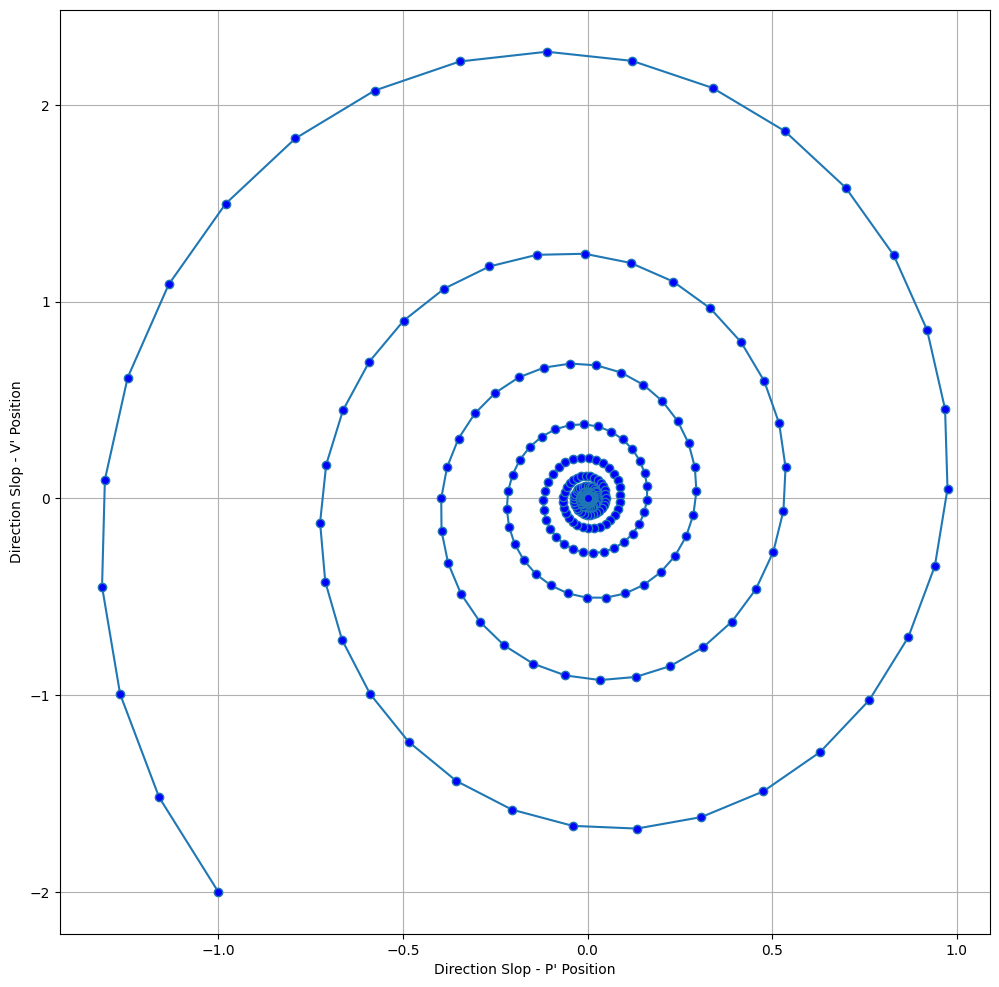

In [62]:
trajectory_be_coordinates_1000={state[0]:state[1] for state in trajectory_be_1000.values()}
plt.figure(figsize=(12,12))
plt.xlabel(r"Direction Slop - P' Position")
plt.ylabel(r"Direction Slop - V' Position")
plt.grid()
plt.plot(trajectory_be_coordinates_1000.keys(), trajectory_be_coordinates_1000.values(),marker='o', markerfacecolor='blue')
plt.show()

## Time Complexity
As iterations increase solutions produced by both methods (BE and FE) exhibit higher time complexity and execution time.

## The role of time steps in FE an BE:
Solutions produced by both methods will improve (i.e., get more accurate) as we decrease the time step. But by increasing the time steps what happens to them is as follows:


In [63]:
print(Backward_Euler_SHO((-1,-2), 0.1,200)[0])
print(Backward_Euler_SHO((-1,-2), 0.11,200)[0])

(3.8446933577231596e-19, 2.7914827505540996e-17)
(2.602791443414448e-19, -4.490221615961207e-19)


## NOTE:
If you take a bigger time step, the red trajectory  using a larger step size spirals in faster inside the fixed point:

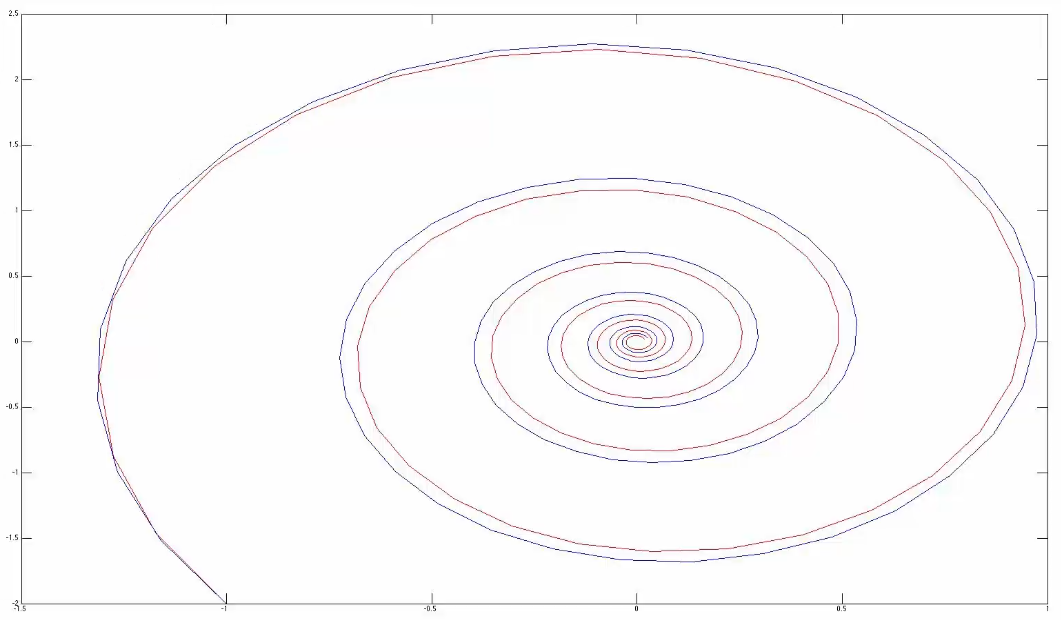

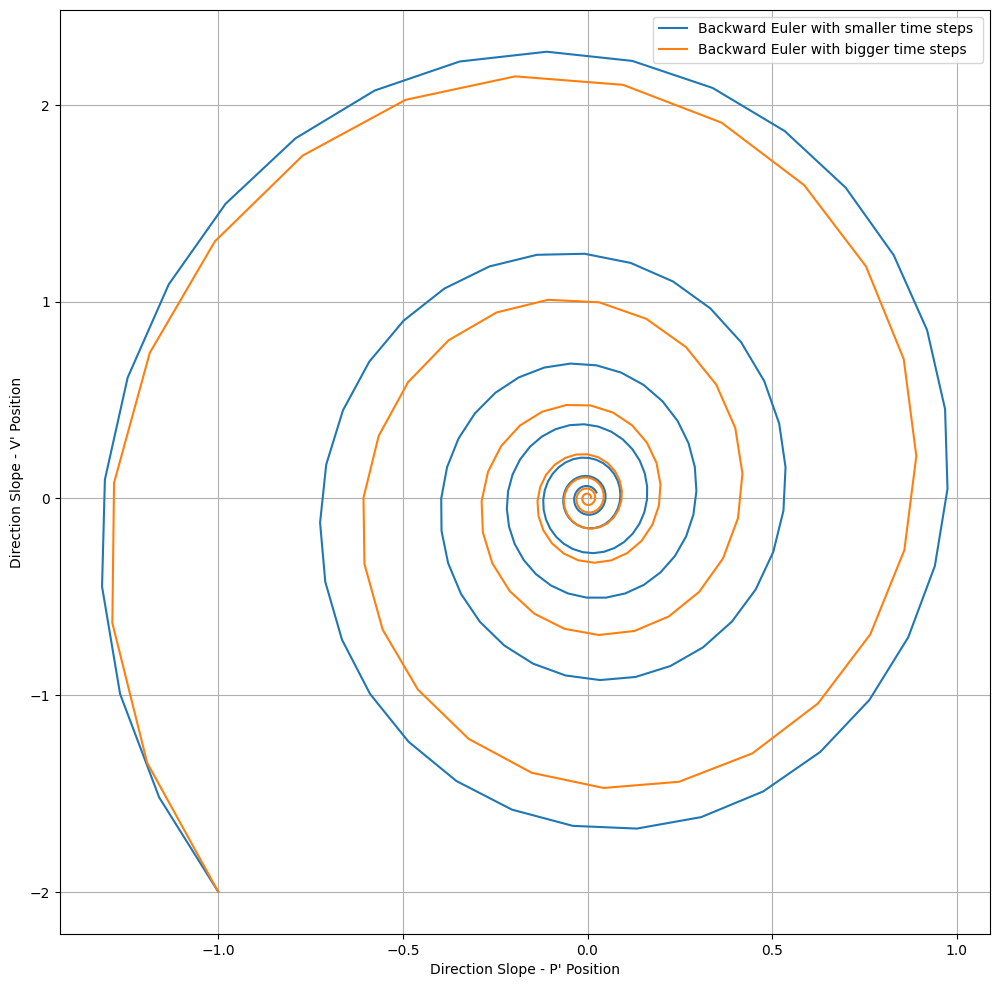

In [39]:
trajectory_be_smallerts = Backward_Euler_SHO((-1,-2), 0.1, 20)[1]
trajectory_be_coordinates_smallerts={state[0]:state[1] for state in trajectory_be_smallerts.values()}
trajectory_be_biggerts = Backward_Euler_SHO((-1,-2), 0.13, 20)[1]
trajectory_be_coordinates_biggerts={state[0]:state[1] for state in trajectory_be_biggerts.values()}

plt.figure(figsize=(12,12))
plt.xlabel(r"Direction Slope - P' Position")
plt.ylabel(r"Direction Slope - V' Position")
plt.grid()
plt.plot(trajectory_be_coordinates_smallerts.keys(), trajectory_be_coordinates_smallerts.values(), label='Backward Euler with smaller time steps ' )
plt.legend()
plt.plot(trajectory_be_coordinates_biggerts.keys(), trajectory_be_coordinates_biggerts.values(), label='Backward Euler with bigger time steps')
plt.legend()
plt.show()